# Dataset Distribution\n\nRenders styled tables showing sample counts from:\n- `cross_architecture_dataset.csv` (raw)\n- `cross_architecture_dataset_clean.csv` (cleaned)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.patches import Patch

BASE_PATH = "/home/tommy/Project/PCBSDA"

CSV_RAW   = f"{BASE_PATH}/datasets/csv/cross_architecture_dataset.csv"
CSV_CLEAN = f"{BASE_PATH}/datasets/csv/cross_architecture_dataset_clean.csv"

SAVE_DIR = Path(f"{BASE_PATH}/ours/outputs/plots/dataset")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Normalize raw CPU names to match clean
CPU_RENAME = {
    'Advanced Micro Devices x86-64': 'x86_64',
    'ARM-32':                         'ARM-32',
    'AArch64':                        'ARM-64',
    'Intel i386-32':                  'Intel',
    'MIPS R3000-32':                  'MIPS',
    'PowerPC-32':                     'PPC',
}

df_raw   = pd.read_csv(CSV_RAW)
df_clean = pd.read_csv(CSV_CLEAN)

df_raw['CPU'] = df_raw['CPU'].map(CPU_RENAME).fillna(df_raw['CPU'])

print(f"Raw   : {df_raw.shape[0]:,} samples | archs: {sorted(df_raw['CPU'].unique())}")
print(f"Clean : {df_clean.shape[0]:,} samples | archs: {sorted(df_clean['CPU'].unique())}")

Raw   : 36,078 samples | archs: ['ARM-32', 'ARM-64', 'Intel', 'MIPS', 'PPC', 'x86_64']
Clean : 33,312 samples | archs: ['ARM-32', 'ARM-64', 'Intel', 'MIPS', 'PPC', 'x86_64']


## Helpers

In [14]:
HEADER_BG  = '#2c3e50'
ROW_COLORS = ['#f4f6f8', '#ffffff']
TOTAL_BG   = '#dce8f5'

# Cell color by count value
def cell_color(v):
    if v > 100:   return '#FADADD'   # 淡玫瑰紅
    if v >= 50:   return '#FFF9C4'   # 淡鵝黃
    return '#CFD8DC'                  # 藍灰（0–49）


def render_family_arch_table(df, title, save_path):
    """Family × Architecture crosstab, cells colored by count."""
    pivot = df.groupby(['family', 'CPU']).size().unstack(fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    pivot['Total'] = pivot.sum(axis=1)
    total_row = pivot.sum(axis=0).rename('Total')
    pivot = pd.concat([pivot, total_row.to_frame().T])

    archs      = [c for c in pivot.columns if c != 'Total']
    col_labels = ['Family'] + archs + ['Total']
    rows       = [[idx] + [f'{pivot.loc[idx, c]:,}' for c in pivot.columns]
                  for idx in pivot.index]

    n_rows = len(rows)
    n_cols = len(col_labels)
    fig_w  = max(10, n_cols * 1.3)
    fig_h  = 0.5 * (n_rows + 1) + 0.5
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    table = ax.table(cellText=rows, colLabels=col_labels,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, 1.6)

    # Header
    for ci in range(n_cols):
        table[0, ci].set_facecolor(HEADER_BG)
        table[0, ci].set_text_props(color='white', fontweight='bold')

    # Per-family rows — color each data cell by count
    families = [idx for idx in pivot.index if idx != 'Total']
    for ri, fam in enumerate(families, start=1):
        # Family name cell — white bg
        table[ri, 0].set_facecolor('#ffffff')
        # Arch cells
        for ci, col in enumerate(pivot.columns, start=1):
            v = pivot.loc[fam, col]
            table[ri, ci].set_facecolor(cell_color(v))
            if col == 'Total':
                table[ri, ci].set_text_props(fontweight='bold')

    # Total row
    for ci in range(n_cols):
        table[n_rows, ci].set_facecolor(TOTAL_BG)
        table[n_rows, ci].set_text_props(fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor='#FADADD', edgecolor='#ccc', label='> 100'),
        Patch(facecolor='#FFF9C4', edgecolor='#ccc', label='50 – 100'),
        Patch(facecolor='#CFD8DC', edgecolor='#ccc', label='< 50 / 0'),
    ]
    ax.legend(handles=legend, loc='lower right', fontsize=8.5,
              framealpha=0.9, edgecolor='#ccc', title='Count', title_fontsize=8.5)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    plt.tight_layout(pad=0.4)
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_path}")

## Raw Dataset

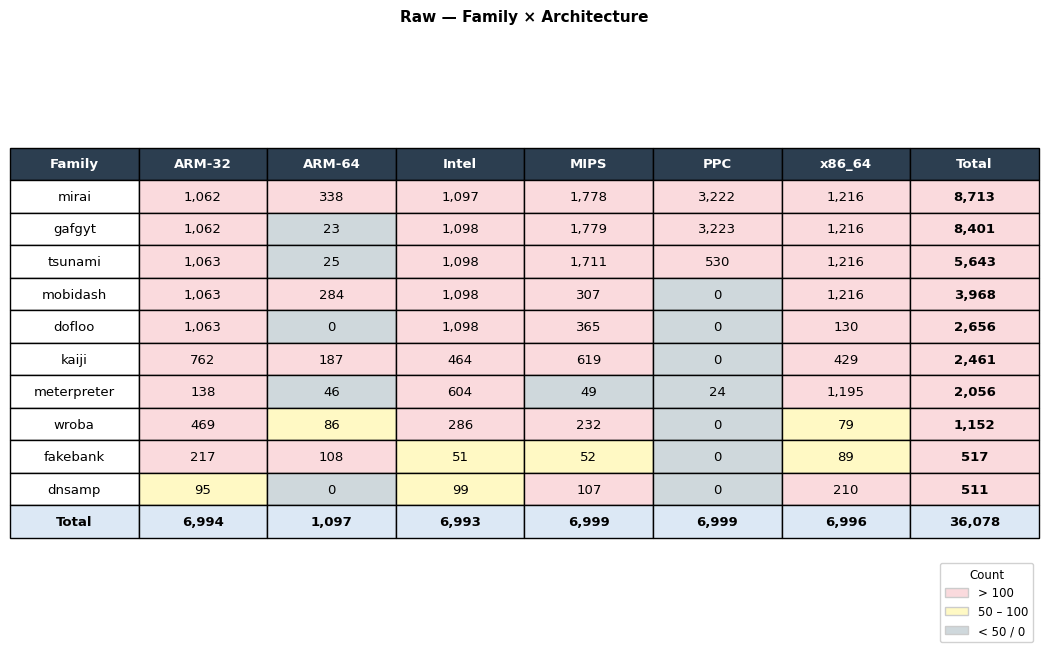

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/dataset/raw_family.png


In [15]:
render_family_arch_table(df_raw, 'Raw — Family × Architecture', SAVE_DIR / 'raw_family.png')

## Clean Dataset

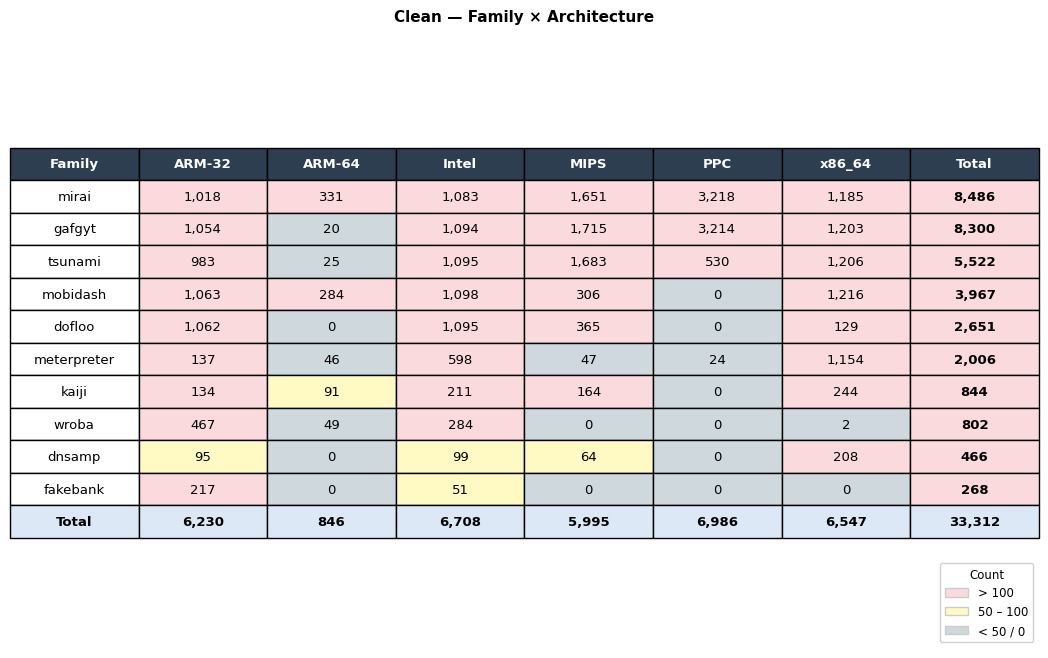

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/dataset/clean_family.png


In [16]:
render_family_arch_table(df_clean, 'Clean — Family × Architecture', SAVE_DIR / 'clean_family.png')